In [18]:
using JuMP, Ipopt, Plots, QuadGK, DataFrames # For accurate integration of the map

In [24]:
# Plot Settings
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=2,
    guidefontsize=14,
    tickfontsize=14,
    legendfontsize=10,
    titlefontsize=18
)

In [51]:
# ==========================================
# 1. Physics & Environment
# ==========================================
const L = 100.0             # Total Path Length (m)
const E_budget = 5.0 * 3600.0     # Total Energy Budget (Wh to J)
const u_min = 0.0           # Min feasible speed (m/s)
const u_max = 2.5           # Max speed (m/s)
const kh = 10.0             # Hotel Load (W)
const km = 83.0              # Drag Coefficient
const alpha = 0.5          # Decay rate
const S_scale = 1.0         # Sensing magnitude

# Environment Map (Gaussian Hotspots)
function sensing_rate_continuous(s)
    peak1 = 0.5 * exp(-((s - 30)^2) / (2 * 5^2)) 
    peak2 = 0.8 * exp(-((s - 80)^2) / (2 * 2^2)) # Sharper peak
    return 0.05 + S_scale * (peak1 + peak2)
end

# Anti-aliasing: Integrate S over the segment
function get_segment_S(s_start, s_end)
    val, err = quadgk(sensing_rate_continuous, s_start, s_end)
    return val / (s_end - s_start)
end


get_segment_S (generic function with 1 method)

In [52]:

# ==========================================
# 2. Optimization Routine (Trapezoidal)
# ==========================================
function solve_optimal_trajectory(N)
    ds = L / N
    S_vals = [get_segment_S((i-1)*ds, i*ds) for i in 1:N]
    
    model = Model(Ipopt.Optimizer)
    set_silent(model)
    
    # --- Variables ---
    # dt: Dwell time per segment
    # q:  Clarity state at segment boundaries (N+1 points)
    @variable(model, ds/u_max <= dt[1:N] <= ds/u_min)
    @variable(model, 0 <= q[1:N+1] <= 1.0)
    
    # --- Objective: Trapezoidal Integration of Clarity ---
    # Maximize integral of q(t)
    @objective(model, Max, sum( 0.5 * (q[i] + q[i+1]) * dt[i] for i in 1:N ))
    
    # --- Constraints ---
    
    # 1. Global Energy Budget
    @NLconstraint(model, sum(kh * dt[i] + km * (ds^3 / dt[i]^2) for i in 1:N) <= E_budget)
    
    # 2. Clarity Dynamics (Trapezoidal Collocation)
    # q_{k+1} - q_k = 0.5 * (f(q_k) + f(q_{k+1})) * dt
    for i in 1:N
        S = S_vals[i]
        
        # Define the dynamics function f(q)
        # We write it inline for JuMP @NLconstraint
        # f(q) = S*(1-q)^2 - alpha*q^2
        
        @NLconstraint(model, 
            q[i+1] == q[i] + 0.5 * dt[i] * (
                (S * (1 - q[i])^2 - alpha * q[i]^2) + 
                (S * (1 - q[i+1])^2 - alpha * q[i+1]^2)
            )
        )
    end
    
    # 3. Initial Condition
    @constraint(model, q[1] == 0.0)
    
    # --- Solve ---
    t_start = time()
    optimize!(model)
    solve_time = time() - t_start
    
    # Return Results
    if termination_status(model) == MOI.LOCALLY_SOLVED
        return objective_value(model), solve_time, value.(dt), value.(q)
    else
        return NaN, NaN, [], []
    end
end


solve_optimal_trajectory (generic function with 1 method)

In [53]:
N_values = [10, 25, 50, 100, 200, 400, 600, 1000, 2500, 5000, 7500, 10000]
results_obj = []
results_time = []
trajectories = []
sim_times = []
results_q = []

println("Running Grid Independence Sweep...")
for N in N_values
    print("  N = $N ... ")
    obj, t, dts, qs = solve_optimal_trajectory(N)
    push!(results_obj, obj)
    push!(results_time, t)
    push!(sim_times, dts)
    push!(results_q, qs)
    
    # Store speed profile for plotting
    speeds = (L/N) ./ dts
    push!(trajectories, speeds)
    println("Done. J = $(round(obj, digits=2)), Time = $(round(t, digits=3))s")
end

# Create results table
results_table = DataFrame(
    N = N_values,
    ObjectiveValue = round.(results_obj, digits=2),
    ComputeTime = round.(results_time, digits=3)
)

println("\n" * "="^60)
println("Grid Independence Sweep Results")
println("="^60)
println(results_table)
println("="^60)

# Export to LaTeX
using DataFrames
open("results_table.tex", "w") do f
    write(f, "\\begin{table}\n")
    write(f, "    \\centering\n")
    write(f, "    \\begin{tabular}{ccc}\n")
    write(f, "        \\hline\n")
    write(f, "        N & Objective Function Value & Compute Time (s) \\\\\n")
    write(f, "        \\hline\n")
    for i in eachindex(N_values)
        write(f, "        $(N_values[i]) & $(round(results_obj[i], digits=2)) & $(round(results_time[i], digits=3))\\\\\n")
    end
    write(f, "        \\hline\n")
    write(f, "    \\end{tabular}\n")
    write(f, "    \\caption{Objective function values and computation times for varying grid resolutions.}\n")
    write(f, "    \\label{tab:grid_resolution}\n")
    write(f, "\\end{table}\n")
end

println("LaTeX table exported to results_table.tex")

Running Grid Independence Sweep...
  N = 10 ... Done. J = 735.26, Time = 0.028s
  N = 25 ... Done. J = 816.64, Time = 0.016s
  N = 50 ... Done. J = 869.07, Time = 0.02s
  N = 100 ... Done. J = 886.6, Time = 0.062s
  N = 200 ... Done. J = 891.34, Time = 0.106s
  N = 400 ... Done. J = 892.55, Time = 0.338s
  N = 600 ... Done. J = 892.77, Time = 0.441s
  N = 1000 ... Done. J = 892.89, Time = 0.531s
  N = 2500 ... Done. J = 892.94, Time = 1.096s
  N = 5000 ... Done. J = 892.95, Time = 10.802s
  N = 7500 ... Done. J = 892.95, Time = 12.584s
  N = 10000 ... Done. J = 892.95, Time = 16.37s

Grid Independence Sweep Results
12×3 DataFrame
 Row │ N      ObjectiveValue  ComputeTime 
     │ Int64  Float64         Float64     
─────┼────────────────────────────────────
   1 │    10          735.26        0.028
   2 │    25          816.64        0.016
   3 │    50          869.07        0.02
   4 │   100          886.6         0.062
   5 │   200          891.34        0.106
   6 │   400          89

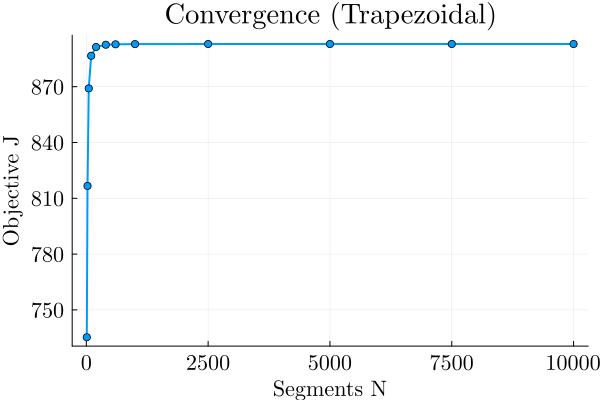

In [54]:
p1 = plot(N_values, results_obj, marker=:circle, title="Convergence (Trapezoidal)", 
          ylabel="Objective J", xlabel="Segments N", legend=false, lw=2)


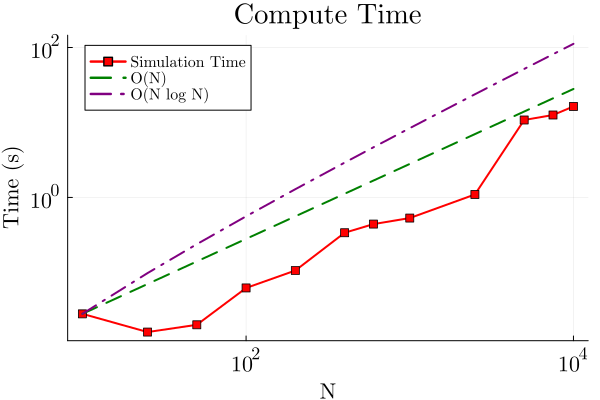

In [55]:

p2 = plot(N_values, results_time, marker=:square, color=:red,
    xaxis=:log, yaxis=:log, title="Compute Time",
    ylabel="Time (s)", xlabel="N", lw=2, label="Simulation Time")
idx = findfirst(!isnan, results_time)
if idx === nothing
    k1 = 1.0
    k2 = 1.0
    k3 = 1.0
else
    k1 = results_time[idx] / N_values[idx]
    k2 = results_time[idx] / (N_values[idx]^2)
    k3 = results_time[idx] / (N_values[idx] * log(N_values[idx]))
end

plot!(p2, N_values, k1 .* N_values, lw=2, ls=:dash, color=:green, label="O(N)")
#plot!(p2, N_values, k2 .* (N_values .^ 2), lw=2, ls=:dot, color=:blue, label="O(N^2)")
plot!(p2, N_values, k3 .* N_values .* log.(N_values), lw=2, ls=:dashdot, color=:purple, label="O(N log N)")

plot!(legend=:topleft)

savefig(p2, "compute_time.png")
plot!()


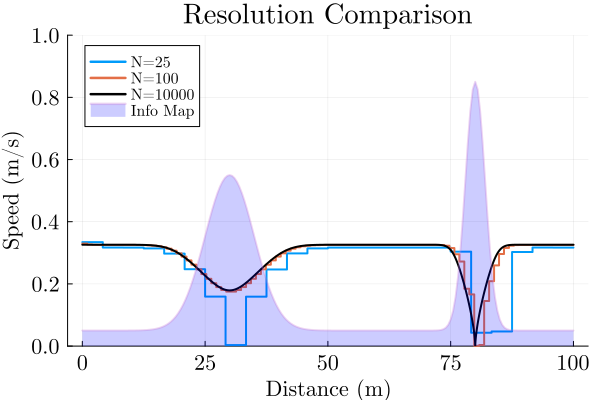

In [56]:

# Speed Profile Comparison
p3 = plot(title="Resolution Comparison", xlabel="Distance (m)", ylabel="Speed (m/s)")
# Plot Coarse
s_coarse = range(0, L, length=length(trajectories[2])) # N=25
plot!(p3, s_coarse, trajectories[2], linetype=:step, label="N=$(N_values[2])", lw=2)

s_mid = range(0, L, length=length(trajectories[4])) # N=100
plot!(p3, s_mid, trajectories[4], linetype=:step, label="N=$(N_values[4])", lw=2)

# Plot Fine
s_fine = range(0, L, length=length(trajectories[end])) # N=400
plot!(p3, s_fine, trajectories[end], label="N=$(N_values[end])", color=:black)
# Overlay Map
s_map = 0:0.5:L
plot!(p3, s_map, sensing_rate_continuous.(s_map), fill=(0,0.2,:blue), label="Info Map", alpha=0.3)
ylims!(p3, 0, 1.0)

final_plot = plot!(legend=:topleft)
savefig(final_plot, "grid_independence_sweep.png")
plot!()

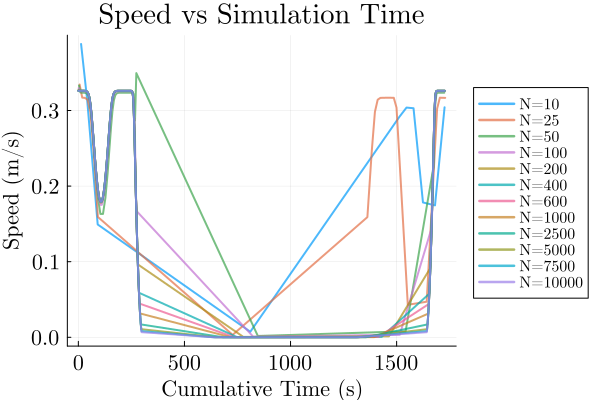

In [57]:
# Speed vs Simulation Time
p = plot(title="Speed vs Simulation Time", xlabel="Cumulative Time (s)", ylabel="Speed (m/s)")
for (i, N) in enumerate(N_values)
    dts = sim_times[i]
    speeds = trajectories[i]
    m = min(length(dts), length(speeds))
    tmid = cumsum(dts[1:m]) .- dts[1:m] ./ 2
    plot!(p, tmid, speeds[1:m], label="N=$(N)", lw=2, alpha=0.7)
end
plot!(legend=:outerright)
savefig(p, "speed_vs_simtime.png")
plot!()